<a href="https://colab.research.google.com/github/root-epifit/HPC_Sber_2025/blob/main/SberUniversity_Python_GPUs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Thu Aug 14 15:45:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             29W /   70W |     118MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
### cupy
### 1. find out version of cuda
### !nvcc --version
### install correct version of cupy
### !pip install cupy-cuda11x  --- something like this

In [ ]:
!nvcc --version

In [ ]:
import cupy as cp

1. Абстрактное использование GPU : `a @ b`
2. Среднеуровневые кастомные программки: `ElementwiseKernel` + некое подобие контроля
3. JIT: Python syntax + полный контроль запуска
4. `RawKernel` (C код передаем строкой библиотеке)

Библиотека cupy
====

Является почти полным переносом функциональности `numpy` на GPU (NVidia, AMD RoCm).

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from cupyx.profiler import benchmark


In [ ]:
N = 2**10

h_a = np.random.rand(N, N).astype(np.float32)
h_b = np.eye(N, dtype = np.float32)

In [ ]:
%%timeit
h_c = h_a @ h_b

22.5 ms ± 4.16 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
d_a = cp.random.rand(N, N).astype(cp.float32)
d_b = cp.eye(N, dtype = cp.float32)

In [ ]:
def matmul(a, b):
    return a @ b

In [ ]:
%%timeit -n 1 -r 1

d_c = d_a @ d_b
cp.cuda.Device().synchronize()

## почему сначала 500мс, а затем 1мс

1.16 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
%%timeit -n 1 -r 1

d_c = d_a @ d_b
cp.cuda.Device().synchronize()



1.12 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
20e-3/500e-6

Измерение времени выполнения на GPU:

In [ ]:
print(benchmark(matmul, (d_a, d_b), n_repeat=10000, n_warmup=10))

matmul              :    CPU:    40.892 us   +/- 18.519 (min:    27.752 / max:   351.954) us     GPU-0:   528.755 us   +/- 47.801 (min:   466.912 / max:   960.032) us


In [ ]:
print(benchmark(my_func, (a,), n_repeat=20))

In [ ]:
%%timeit
# 1. CPU tells GPU to launch kernel
# 2. After that CPU is free

d_c = matmul(d_a, d_b)

# 3. if you want to measure total time we just need to sync CPU and GPU
cp.cuda.Device(0).synchronize()


In [ ]:
with cp.cuda.Device(0):
    d_a_0 = cp.empty(1000)

'''
with cp.cuda.Device(1):
    ....
'''

Копирование данных с ЦПУ на ГПУ и обратно (помним о накладных)

In [ ]:
h_a = np.ones(2**3, dtype = np.uint8)
d_a = cp.ones(2**3, dtype = cp.uint8)

h_b = d_a.get()  ## explicit copy from GPU to CPU, a-la cudaMemcpy(...,...,..., cudaMemcpyDeviceToHost)
h_c = np.linspace(0, 10, 100)
d_c = cp.array(h_c)   ## explicit copy from CPU to GPU                          cudaMemcpyHosttoDevice

In [ ]:
d_a = cp.linspace(0, 10, 1024, dtype=cp.float32)
d_b = cp.linspace(0, 10, 1024, dtype=cp.float32)

d_c  = d_a + d_b

In [ ]:
print(d_c.get())

[0.0000000e+00 1.9550342e-02 3.9100684e-02 ... 1.9960899e+01 1.9980450e+01
 2.0000000e+01]


In [ ]:
print(d_c)   ### BAD: you don't notice the copying overhead

In [ ]:
plt.plot(d_c.get())

In [ ]:
### there is a limit  of number of threads per block = 1024

In [ ]:
%%writefile helloworld.cu
#include <stdio.h>

/*_device__ __host__ float sum(a,b) {
    return a+b;
}
*/

__global__ void helloKernel() {

   // gid inside the block
   int gid = threadIdx.x + threadIdx.y * blockDim.x + threadIdx.z * blockDim.x * blockDim.y;

   int bid = blockIdx.x + blockIdx.y * gridDim.x + blockIdx.z * gridDim.x * gridDim.y;

   gid = gid + bid * blockDim.x * blockDim.y * blockDim.z;


   printf("Hello from tx = %d, ty = %d, tz = %d, gid = %d\n",
          threadIdx.x, threadIdx.y, threadIdx.z, gid);

   // a[gid] = a[gid] * a[gid];
   // как дебажить
}

int main() {
    printf("Hello from CPU\n");

    helloKernel<<<dim3(2,1,2),dim3(2,2,2)>>>();

    ///helloKernel<<<65536, 1024>>>

    cudaDeviceSynchronize();
    return 0;
}

Overwriting helloworld.cu


In [ ]:
!nvcc -arch=sm_75 helloworld.cu -o test

In [ ]:
!./test

Hello from CPU
Hello from tx = 0, ty = 0, tz = 0, gid = 8
Hello from tx = 1, ty = 0, tz = 0, gid = 9
Hello from tx = 0, ty = 1, tz = 0, gid = 10
Hello from tx = 1, ty = 1, tz = 0, gid = 11
Hello from tx = 0, ty = 0, tz = 1, gid = 12
Hello from tx = 1, ty = 0, tz = 1, gid = 13
Hello from tx = 0, ty = 1, tz = 1, gid = 14
Hello from tx = 1, ty = 1, tz = 1, gid = 15
Hello from tx = 0, ty = 0, tz = 0, gid = 24
Hello from tx = 1, ty = 0, tz = 0, gid = 25
Hello from tx = 0, ty = 1, tz = 0, gid = 26
Hello from tx = 1, ty = 1, tz = 0, gid = 27
Hello from tx = 0, ty = 0, tz = 1, gid = 28
Hello from tx = 1, ty = 0, tz = 1, gid = 29
Hello from tx = 0, ty = 1, tz = 1, gid = 30
Hello from tx = 1, ty = 1, tz = 1, gid = 31
Hello from tx = 0, ty = 0, tz = 0, gid = 16
Hello from tx = 1, ty = 0, tz = 0, gid = 17
Hello from tx = 0, ty = 1, tz = 0, gid = 18
Hello from tx = 1, ty = 1, tz = 0, gid = 19
Hello from tx = 0, ty = 0, tz = 1, gid = 20
Hello from tx = 1, ty = 0, tz = 1, gid = 21
Hello from tx = 0, 

In [ ]:
%%writefile helloworld.cu
#include <stdio.h>

__device__ int get_gid() {
    int gid = threadIdx.x + threadIdx.y * blockDim.x +
              threadIdx.z * blockDim.x * blockDim.y;

    int bid = blockIdx.x + blockIdx.y * gridDim.x +
              blockIdx.z * gridDim.x * gridDim.y;

    gid = gid + bid * blockDim.x * blockDim.y * blockDim.z;
    return gid;
}

__global__ void helloKernel() {

    int gid = get_gid();

    printf("Hello from gi = %d\n", gid);
}

int main() {

    helloKernel<<<dim3(2,2,2),dim3(2,2,1)>>>();

    // 1024 * 65536 * 65536 * 65536 --> max number of threads

    cudaDeviceSynchronize();
    return 0;
}

Overwriting helloworld.cu


In [ ]:
!nvcc -arch=sm_75 helloworld.cu -o test

In [ ]:
!./test

Hello from gi = 4
Hello from gi = 5
Hello from gi = 6
Hello from gi = 7
Hello from gi = 24
Hello from gi = 25
Hello from gi = 26
Hello from gi = 27
Hello from gi = 16
Hello from gi = 17
Hello from gi = 18
Hello from gi = 19
Hello from gi = 8
Hello from gi = 9
Hello from gi = 10
Hello from gi = 11
Hello from gi = 28
Hello from gi = 29
Hello from gi = 30
Hello from gi = 31
Hello from gi = 12
Hello from gi = 13
Hello from gi = 14
Hello from gi = 15
Hello from gi = 0
Hello from gi = 1
Hello from gi = 2
Hello from gi = 3
Hello from gi = 20
Hello from gi = 21
Hello from gi = 22
Hello from gi = 23


In [ ]:
%%writefile square.cu
#include <stdio.h>
// есть одномерный массив а
// задача: поэлементно возвести в квадрат


__device__ int get_gid() {
    int gid = threadIdx.x + threadIdx.y * blockDim.x +
              threadIdx.z * blockDim.x * blockDim.y;

    int bid = blockIdx.x + blockIdx.y * gridDim.x +
              blockIdx.z * gridDim.x * gridDim.y;

    gid = gid + bid * blockDim.x * blockDim.y * blockDim.z;
    return gid;
}



__global__ void initKernel(float* d_a, int N) {
    int gid = get_gid();

    if (gid < N) {
        d_a[gid] = gid;
    }

    //if (gid == 0) {
    //    while(1);
    //}
    //__syncthreads();
}

__global__ void squareKernel(float* d_a, int N) {
    int gid = get_gid();

    if (gid < N) {
        d_a[gid] = d_a[gid]*d_a[gid];
    }
}

__global__ void sumvecKernel(float* d_a, float* d_b, float* d_result, int N) {
    int gid = get_gid();
    //int massiv[10];

    if (gid < N) {
        d_result[gid] = d_a[gid] + d_b[gid];
    }
}

static const int N = 16;

int main() {
    // массив на ГПУ -- инициализировать
    float* d_a;
    cudaMalloc(&d_a, N * sizeof(float));    // cupy.empty(N, dtype=cp.float32)
    // массив на ЦПУ с результатами инициализировать
    float* h_a = (float*)malloc(N*sizeof(float));

    // kernel с заполнением массива на ГПУ
    initKernel<<<1, N>>>(d_a, N);
    // barrier
    // kernel square вызов

    squareKernel<<<1, N>>>(d_a, N);
    //cudaDeviceSynchronize();

    // получить результаты с ГПУ
    cudaMemcpy(h_a, d_a, N * sizeof(float), cudaMemcpyDeviceToHost);   // h_a=d_a.get() in cupy

    // напечатать результаты
    for (int n = 0; n < N; ++n) {
        printf("%f\t", h_a[n]);
    }
    printf("\n");

    // освободить память
    cudaFree(d_a);
    free(h_a);
    return 0;
}

Overwriting square.cu


In [ ]:
!nvcc -arch=sm_75 square.cu -o test

In [ ]:
!./test

^C


In [ ]:
%%writefile helloworld.cu

#include <stdio.h>

__global__ void helloKernel(int* a, size_t N) {



    if (gid < N) {
        a[gid] = gid;
    }
    printf("Hello from tx = %d, from ty = %d, tz = %d, bx = %d, my gid = %d\n",
           threadIdx.x, threadIdx.y, threadIdx.z, blockIdx.x, gid);
}

static const size_t N = 16;

int main() {
    int* d_a;
    int* h_a;
    cudaMalloc(&d_a, N * sizeof(int));
    h_a = (int*)malloc(N * sizeof(int));

    // 1024 * 65536^3

    helloKernel<<<dim3(1,2,2),dim3(2,2,1)>>>(d_a, N);
    // grid of blocks
    // block of threads
    cudaDeviceSynchronize();
    cudaMemcpy(h_a, d_a, N * sizeof(int), cudaMemcpyDeviceToHost);

    for (int n=0; n<N;++n) {
        printf("%d\t", h_a[n]);
    }
    printf("\n");

    free(h_a);
    cudaFree(d_a);
    return 0;
}

In [ ]:
!nvcc -arch=sm_75 helloworld.cu -o test

In [ ]:
!./test

In [ ]:
%%writefile hello.cpp

#include <iostream>

int main() {


    std::cout << "Hello" << std::endl;
    return 0;
}

In [ ]:
!g++ hello.cpp -o test

In [ ]:
### Hello world CUDA
%%writefile helloworld.cu

#include <stdio.h>

__host__ __device__ int sum(int a, int b) {
    return a + b
}

__device__ int get_global_idx() {
    int gid = threadIdx.x + threadIdx.y * blockDim.x + threadIdx.z * blockDim.x * blockDim.y;
    int bid = blockIdx.x + blockIdx.y * gridDim.x + blockIdx.z * gridDim.x * gridDim.y;
    gid = gid + bid * blockDim.x * blockDim.y * blockDim.z;
    return gid;
}

__global__ void helloKernel() {
    int gid = get_global_idx();
    printf("Hello tx=%d ty=%d tz=%d gid=%d\n", threadIdx.x, threadIdx.y, threadIdx.z, gid);
}

int main() {
    helloKernel<<<dim3(2,2,2), dim3(2,2,2)>>>();
    // grid of blocks
    // block of threads
    cudaDeviceSynchronize();
    return 0;
}

In [ ]:
!nvcc helloworld.cu -o test

In [ ]:
!./test

In [ ]:
### Hello world CUDA
%%writefile helloworld.cu

#include <stdio.h>

__device__ size_t get_global_idx() {
    size_t gid = threadIdx.x + blockDim.x * threadIdx.y + blockDim.x * blockDim.y * threadIdx.z;
    gid += (blockIdx.x + gridDim.x * blockIdx.y + gridDim.x * gridDim.y * blockIdx.z)
                                            * blockDim.x * blockDim.y * blockDim.z;
    return gid;
}

__global__ void hello() {
    size_t gid = get_global_idx();
    printf("tid = %d\tbid = %d\tgid = %zu\n", threadIdx.x, blockIdx.x, gid);
}

int main() {
    hello<<<dim3(2,2,2),dim3(2,2,2)>>>();
    # grid of blocks
    # block of threads
    cudaDeviceSynchronize();
    return 0;
}

In [ ]:
!nvcc helloworld.cu -o test

In [ ]:
!./test
# warp

In [ ]:
%%writefile square.cu

#include <stdio.h>
#include <inttypes.h>

static const size_t N = 32;

__device__ size_t get_index() {
    size_t tid = threadIdx.x + threadIdx.y * blockDim.x +
                 threadIdx.z * blockDim.x * blockDim.y;

    size_t bid = blockIdx.x + blockIdx.y * gridDim.x +
                 blockIdx.z * gridDim.x * gridDim.y;

    size_t global_idx = bid * blockDim.x * blockDim.y * blockDim.z + tid;
    return global_idx;
}

__global__ void init_kernel(float* d_a, size_t N) {
    size_t global_idx = get_index();

    if (global_idx < N) {
        d_a[global_idx] = global_idx;
    }
}

__global__ void square_kernel(float* d_a, float* d_result, size_t N) {
    size_t global_idx = get_index();

    if (global_idx < N) {
        d_result[global_idx] = d_a[global_idx] * d_a[global_idx];
    }
}


int main() {
    // 1. Allocate a vector in GPU
    float* d_a; // tell that there will be a single-presicion vector
    float* d_result;

    cudaMalloc(&d_a, N * sizeof(float));   // analog to cp.empty(N, dtype = cp.float32)
    cudaMalloc(&d_result, N * sizeof(float));

    float* h_result = (float*)malloc(N * sizeof(float));

    // 2. Initialize array (vector) with a kernel
    init_kernel<<<dim3(2,2,2), dim3(2,2,1)>>>(d_a, N);

    // intrinsic barrier
    // 2. Launch kernel that will square vector elementwise
    square_kernel<<<dim3(2,2,1), dim3(2,2,2)>>>(d_a, d_result, N);

    // d_result[gid] = d_a[gid] * d_a[gid];

    // 3. Get results back
    cudaMemcpy(h_result, d_result, N * sizeof(float), cudaMemcpyDeviceToHost);
    //printf("%p\n", d_result);


    // 4. Print results

    for (int i = 0; i < N; ++i) {
        printf("%f ", h_result[i]);
    }
    printf("\n");

    free(h_result);
    cudaFree(d_result);
    cudaFree(d_a);

    return 0;
}

In [ ]:
!nvcc -arch=sm_75 square.cu -o test

In [ ]:
!./test

cupy user-defined kernels
------
https://docs.cupy.dev/en/stable/user_guide/kernel.html

In [ ]:
import cupy as cp


In [ ]:
### write vectoradd

sum_kernel = cp.ElementwiseKernel(
   'float32 x, float32 y, float32 z',
   'float32 s',
   's = x + y + z',
   'sum_kernel')

square_kernel = cp.ElementwiseKernel(
    'float32 x',
    'float32 s',
    's = x * x',
    'square_kernel'
)

# cp.sum(d_a)

In [ ]:
d_a = cp.ones(1024 * 1024, dtype=cp.float32)
d_b = cp.ones(1024 * 1024, dtype=cp.float32) * 3
d_c = cp.empty(1024 * 1024, dtype=cp.float32)



In [ ]:
%%timeit -n 1 -r 1
sum_kernel(d_a, d_b, d_a, d_c, block_size=1);
cp.cuda.Device().synchronize()


3.89 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
#square_kernel(d_b, d_c);
#print(d_c)

# warp -- 32 threads

In [ ]:
%%timeit -n 1 -r 1

sum_kernel(d_a, d_b, d_a, d_c, block_size=1024);
cp.cuda.Device().synchronize()

# warp = 32 threads

# 1  -- 1.3
# 2  -- 0.6
# 4  -- 0.32
# 32 -- 0.07
# 128 -- 0.064
# 256 -- ====



```C
int add(int a, int b) {
    return a+b;
}

float add(float a, float b) {
    return a+b;
}

template<typename T>
T add(T a, T b) {
    return a + b;
}

float a = 0.0;
float b = 0.0;

add(a, b);

```

In [ ]:
import cupy as cp

In [ ]:
### write vectoradd templated

sum_kernel_t = cp.ElementwiseKernel(
   'T x, T y',
   'T z',
   'z = x + y',
   'sum_kernel')

### thread --> gid
### z[gid] = x[gid] + y[gid]

In [ ]:
d_a = cp.ones(1024 * 2, dtype=cp.float32)
d_b = cp.ones(1024 * 2, dtype=cp.float32) * 3
d_c = cp.empty(1024 * 2, dtype=cp.float32)

sum_kernel_t(d_a, d_b, d_c, block_size=1024);

In [ ]:
d_c

http://i.uran.ru/webcab/system/files/bookspdf/tehnologiya-cuda-v-primerah-vvedenie-v-programmirovanie-graficheskih-proces/tenologiya.pdf

In [ ]:
d_c

In [ ]:
### raw argument specifier

# x, y -- 1D vectors
# x[0] + y[N-1] -> z[0]
# x[1] + y[N-2] -> z[1]


# x[i] --> y[g(i)]
# x[0]  + y[N-1-0]
# x[1]  + y[N-1-1]

add_reverse = cp.ElementwiseKernel(
    'T x, raw T y', 'T z',
    'z = x + y[_ind.size() - i - 1]',          # i --- gid;   N
    'add_reverse')

### thread --> gid
### x[gid], z[gid]
### z[gid] = x[gid] + y[N - gid - 1]

In [ ]:
import pprint
pprint.pprint(add_reverse.cached_code)



('\n'
 '    typedef int T;\n'
 '\n'
 '    \n'
 '    extern "C" __global__ void add_reverse(const CArray<int, 1, 1, 1> '
 '_raw_x, const CArray<int, 1, 1, 1> y, CArray<int, 1, 1, 1> _raw_z, '
 'CIndexer<1, 1> _ind) {\n'
 '      ;\n'
 '      #pragma unroll 1\n'
 '      CUPY_FOR(i, _ind.size()) {\n'
 '        _ind.set(i);\n'
 '        const T &x = _raw_x[_ind.get()];\n'
 'T &z = _raw_z[_ind.get()];\n'
 'z = x + y[_ind.size() - i - 1];\n'
 '      }\n'
 '      ;\n'
 '    }\n'
 '    ')


In [ ]:
d_a = cp.linspace(0, 1024 * 2, 1024 * 2, dtype=cp.int32, endpoint=False)
d_b = cp.linspace(0, 1024 * 2, 1024 * 2, dtype=cp.int32, endpoint=False)
d_c = cp.empty(1024 * 2, dtype=cp.int32)

add_reverse(d_a, d_b, d_c, block_size=32)

array([2047, 2047, 2047, ..., 2047, 2047, 2047], dtype=int32)

In [ ]:
import cupy as cp

### reduction kernel
# https://docs.cupy.dev/en/stable/user_guide/kernel.html#reduction-kernels

# 1 2 3 4 5 6 7 8
# OP: +    identity: 0
# 1+2+3+4+5+6+7+8 = 36

# 1 2 3 4 5 6 7 8
# 1 4 9 16 25 36 49 64   ---> map
# summa                  ---> reduction
# sqrt(summa)            ---> post-reduction map

reduce_kernel = cp.ReductionKernel(
    'T x',  # input params
    'T y',  # output params
    'x * x',  # map
    'a + b',  # reduce
    'y = sqrt(a)',  # post-reduction map
    '0',  # identity value
    'reduce'  # kernel name
)

d_x = cp.arange(10, dtype=cp.float32)

d_y = reduce_kernel(d_x)
print(d_y)
#print(cp.sqrt(cp.sum(x*x)))

16.881943


In [ ]:
### raw kernel

add_kernel = cp.RawKernel(r'''
extern "C" __global__
void my_add(const float* x1, const float* x2, float* y, int N) {
    size_t gid = threadIdx.x + blockDim.x * threadIdx.y +
                 blockDim.x * blockDim.y * threadIdx.z;
    gid += (blockIdx.x + gridDim.x * blockIdx.y + gridDim.x * gridDim.y * blockIdx.z)
            * blockDim.x * blockDim.y * blockDim.z;
    if (gid < N) {
        y[gid] = x1[gid] + x2[gid];
    }
}
''', 'my_add')


# RawModule

In [ ]:
d_x = cp.linspace(0, 32, 32, dtype=cp.float32, endpoint=False)
d_y = cp.linspace(0, 32, 32, dtype=cp.float32, endpoint=False)
d_z = cp.zeros_like(d_x)

add_kernel((16,4,1),(32,8,1),(d_x, d_y, d_z, 32))

In [ ]:
d_z

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
       26., 28., 30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50.,
       52., 54., 56., 58., 60., 62.], dtype=float32)

In [ ]:
### jit rawkernel
import cupy as cp
from cupyx import jit

@jit.rawkernel()
def elementwise_add(x, y, size):
    tid = jit.blockIdx.x * jit.blockDim.x + jit.threadIdx.x  # gid
    #ntid = jit.gridDim.x * jit.blockDim.x
    #size_t gid = threadIdx.x + blockDim.x * threadIdx.y + blockDim.x * blockDim.y * threadIdx.z;
    #gid += (blockIdx.x + gridDim.x * blockIdx.y + gridDim.x * gridDim.y * blockIdx.z) * blockDim.x * blockDim.y * blockDim.z;

    if tid < size:
        x[tid] = x[tid] + y[tid]

size = cp.uint32(1024)

d_x = cp.linspace(0, 1024, size, dtype=cp.float32, endpoint=False)
d_y = cp.linspace(0, 1024, size, dtype=cp.float32, endpoint=False)

elementwise_add((1,1,1), (1024,1,1), (d_x, d_y, cp.uint32(1024)))  # RawKernel style

#assert (x == y).all()
#elementwise_copy[128, 1024](x, y, size)  #  Numba style
#assert (x == y).all()

print(d_x)

[0.000e+00 2.000e+00 4.000e+00 ... 2.042e+03 2.044e+03 2.046e+03]


/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
d_x


In [ ]:
import pprint
pprint.pp(elementwise_add.cached_code)

('\n'
 'extern "C" __global__ void elementwise_add(CArray<float, 1, true, true> x, '
 'CArray<float, 1, true, true> y, unsigned int size) {\n'
 '  unsigned int tid = ((blockIdx.x * blockDim.x) + threadIdx.x);\n'
 '  if ((tid < size)) {\n'
 '    x[tid] = (x[tid] + y[tid]);\n'
 '  }\n'
 '  else {\n'
 '  }\n'
 '}')


In [ ]:
import cupy as cp
from cupyx import jit
import matplotlib.pyplot as plt


d_x = cp.linspace(0, 10, 10, dtype=cp.float64)
d_y = cp.linspace(0, 10, 10, dtype=cp.float64)
d_z = cp.zeros(10, dtype=cp.float64)



In [ ]:
# 1e6 чисел от -1 до 1
# histogram[0] --- кол-во отрицательных чисел в выборке
# histogram[1] --- кол-во положительных чисел + 0

# histogram[0] += 1    read, modify, write

# 0..0.1    0.1..0.2

In [ ]:
@jit.rawkernel()
def histogram_jit(data, bins_data, n_bins, min_x, max_x):
    bid = jit.blockIdx.z * jit.gridDim.x * jit.gridDim.y + \
          jit.blockIdx.y * jit.gridDim.x + jit.blockIdx.x

    tid = jit.threadIdx.z * jit.blockDim.x * jit.blockDim.y + \
          jit.threadIdx.y * jit.blockDim.x + jit.threadIdx.x

    gid = tid + bid * jit.blockDim.x * jit.blockDim.y * jit.blockDim.z

    dbin = (max_x-min_x)/n_bins

    number = data[gid]
    index = cp.int32(number / dbin)

    bins_data[index] = bins_data[index] + 1   # RMW, race condition



In [ ]:
###### Histogram params #######
n_bins = 10
n_data = 2**20   #3*1024#2**20
max_x  = cp.float32(1.0)
min_x  = cp.float32(0.0)
###############################

d_data         = cp.random.rand(n_data).astype(cp.float32)
d_bins_data    = cp.zeros(n_bins, dtype=cp.uint32)

In [ ]:
histogram_jit((256,2,2), (512,2,1), (d_data, d_bins_data, n_bins, min_x, max_x))

In [ ]:
import matplotlib.pyplot as plt

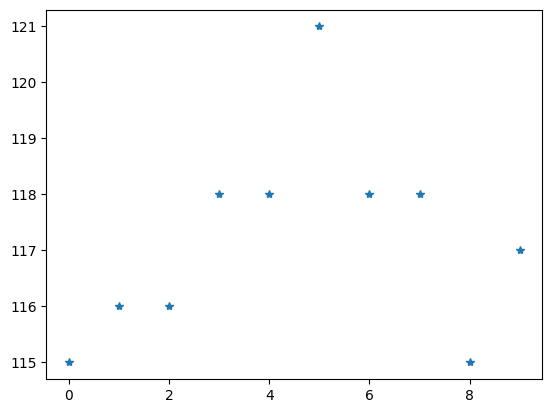

In [ ]:
plt.plot(d_bins_data.get(), '*')

In [ ]:
cp.sum(d_bins_data)

array(1172, dtype=uint64)

In [ ]:
@jit.rawkernel()
def histogram_jit_atomic(data, bins_data, n_bins, min_x, max_x):
    bid = jit.blockIdx.z * jit.gridDim.x * jit.gridDim.y + \
          jit.blockIdx.y * jit.gridDim.x + jit.blockIdx.x

    tid = jit.threadIdx.z * jit.blockDim.x * jit.blockDim.y + \
          jit.threadIdx.y * jit.blockDim.x + jit.threadIdx.x

    gid = tid + bid * jit.blockDim.x * jit.blockDim.y * jit.blockDim.z

    dbin = (max_x-min_x)/n_bins

    number = data[gid]
    index = cp.int32(number / dbin)
    #bins_data[index] = bins_data[index] + 1   # RMW
    jit.atomic_add(bins_data, index, 1)



/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
d_bins_data = cp.zeros(n_bins, dtype=cp.int32)
histogram_jit_atomic((1024,), (1024,), (d_data, d_bins_data, n_bins, min_x, max_x))

In [ ]:
%%timeit -n 1 -r 1
histogram_jit_atomic((1024,), (1024,), (d_data, d_bins_data, n_bins, min_x, max_x))

cp.cuda.Device().synchronize()

886 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
%%timeit -n 1 -r 1
histogram_jit((1024,), (1024,), (d_data, d_bins_data, n_bins, min_x, max_x))

cp.cuda.Device().synchronize()

436 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
cp.sum(d_bins_data)

array(1048576)

(0.0, 150300.0)

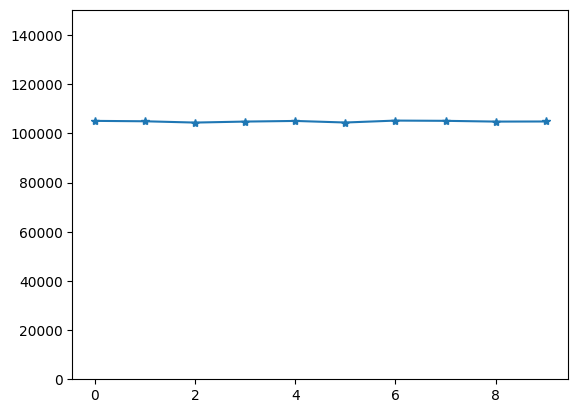

In [ ]:
plt.plot(d_bins_data.get(), '*-')
plt.ylim(0,150300)

In [ ]:
import pprint
pprint.pp(histogram_jit.cached_code)

('\n'
 'extern "C" __global__ void histogram_jit(CArray<float, 1, true, true> data, '
 'CArray<unsigned int, 1, true, true> bins_data, int n_bins, float min_x, '
 'float max_x) {\n'
 '  unsigned int bid = ((((blockIdx.z * gridDim.x) * gridDim.y) + (blockIdx.y '
 '* gridDim.x)) + blockIdx.x);\n'
 '  unsigned int tid = ((((threadIdx.z * blockDim.x) * blockDim.y) + '
 '(threadIdx.y * blockDim.x)) + threadIdx.x);\n'
 '  unsigned int gid = (tid + (((bid * blockDim.x) * blockDim.y) * '
 'blockDim.z));\n'
 '  float dbin = ((float)(max_x - min_x) / (float)(float)(n_bins));\n'
 '  float number = data[gid];\n'
 '  int index = (int)(((float)number / (float)dbin));\n'
 '  bins_data[index] = (bins_data[index] + 1u);\n'
 '}')


In [ ]:
plt.plot(d_bins_data.get())
plt.ylim(0,150)

In [ ]:
#### how to do reduction

# 1   2   3   4   5   6   7   8
#   +       +       +       +         1 step
#   3       7       11      15
#       +               +             2 step
#      10               26
#               +                     3 step
#              36

# log(N)


# 1  2  3  4  5  6  7  8
# 1 + 5
# 2 + 6
# 3 + 7
# 4 + 8

In [ ]:
%%writefile reduction.cu

#include <stdio.h>

static const size_t N = 1024;

__device__ size_t get_index() {
    size_t tid = threadIdx.x + threadIdx.y * blockDim.x +
                 threadIdx.z * blockDim.x * blockDim.y;

    size_t bid = blockIdx.x + blockIdx.y * gridDim.x +
                 blockIdx.z * gridDim.x * gridDim.y;

    size_t global_idx = bid * blockDim.x * blockDim.y * blockDim.z + tid;
    return global_idx;
}

__global__ void init_kernel(float* d_a, size_t N) {
    size_t global_idx = get_index();

    if (global_idx < N) {
        d_a[global_idx] = global_idx;
    }
}

__global__ void reduce_kernel(float* d_a, float* d_result, size_t N) {
    size_t gid = get_index();
    size_t stride = size_t(N / 2);
    // initial stride = 512

    while (stride>0) {
        __syncthreads();
        if (gid < stride) {
            d_a[gid] = d_a[gid] + d_a[gid+stride];

        }

        stride = stride / 2; // private (у каждой нити своя переменная)
    }
    // write result
    if (gid==0) {
      d_result[0] = d_a[0];
    }

}

/*
1 timestep

работает 512 нитей с индексами от 0 до 511]
    d[0] + d[512] ---> d[0]
**  1 + 513 ---> 1
    2 + 514 ---> 2
..
    256 + 768  ----> 256
    511 + 1023 ---> 511


Мы должны убедиться, что на каждом временном шаге (или шаге цикла while)
каждая нить закончила update своего куска массиме.

Синхронизация или барьер

----- stride / 2 = 256
работает 256 нитей от 0 до 255]
    d[0] + d[256] ---> d[0]
**  1 + 257       ---> d[1]
..
    128 + 384     ---> 128

---- stride / 2 = 128
работает 128 нитей от 0 до 127]
    d[0] + d[128]  ---> d[0]
**  1 + 129        ---> d[1]

....
....
----- stride / 2 = 1
работает только 0 нить
    d[0] + d[1] ---> d[0]

   а нить номер 1 так и не пришла.
*/


int main() {
    // 1. Allocate a vector in GPU
    float* d_a; // tell that there will be a single-presicion vector
    float* d_result;

    cudaMalloc(&d_a, N * sizeof(float));   // analog to cp.empty(N, dtype = cp.float32)
    cudaMalloc(&d_result, sizeof(float));


    // 2. Initialize array (vector) with a kernel
    init_kernel<<<dim3(1), dim3(N)>>>(d_a, N);

    // intrinsic barrier

    // 2. Launch kernel that will square vector elementwise
    reduce_kernel<<<dim3(1), dim3(N)>>>(d_a, d_result, N);
    // barrier

    // 3. Get results back
    float h_result = 0;
    cudaMemcpy(&h_result, d_result, 1 * sizeof(float), cudaMemcpyDeviceToHost);
    printf("%e\n", h_result);

    //free(h_result);
    cudaFree(d_result);
    cudaFree(d_a);

    return 0;
}

Overwriting reduction.cu


In [ ]:
!nvcc -arch=sm_75 reduction.cu -o test

In [ ]:
512+256
128 + 256

384

In [ ]:
for n in range(10):
    !./test

5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05


In [ ]:
import numpy as np
a = np.linspace(0,1024,1024, endpoint=False)
np.sum(a)

np.float64(523776.0)

In [ ]:
## with debug info
!nvcc -g -G -arch=sm_75 reduction.cu -o test_debug


In [ ]:
## try compute sanitizer to find missing syncthreads:
!compute-sanitizer --tool synccheck ./test_debug

========= COMPUTE-SANITIZER
5.237760e+05
========= ERROR SUMMARY: 0 errors


In [ ]:
%%writefile faulty.cu
#include <stdio.h>

__global__ void faultyKernel(int *data) {
    __shared__ int sharedData[256];

    int tid = threadIdx.x;
    int gid = blockIdx.x * blockDim.x + tid;

    // Load data into shared memory
    sharedData[tid] = data[gid];  // Each thread loads one element

    // MISSING: __syncthreads();  // Ensures all threads have written their values

    // Simple reduction operation (incorrect due to race condition)
    if (tid < 128) {
        sharedData[tid] += sharedData[tid + 128];
    }

    // MISSING: __syncthreads();  // Required before further reductions

    if (tid < 64) {
        sharedData[tid] += sharedData[tid + 64];
    }

    // Only the first thread writes back the result
    if (tid == 0) {
        data[blockIdx.x] = sharedData[0];
    }
}

int main() {
    int h_data[256], *d_data;

    for (int i = 0; i < 256; i++)
        h_data[i] = 1;

    cudaMalloc(&d_data, 256 * sizeof(int));
    cudaMemcpy(d_data, h_data, 256 * sizeof(int), cudaMemcpyHostToDevice);

    faultyKernel<<<1, 256>>>(d_data);

    cudaDeviceSynchronize();

    cudaMemcpy(h_data, d_data, 256 * sizeof(int), cudaMemcpyDeviceToHost);

    printf("Output: %d\n", h_data[0]); // Expecting 256 but might get incorrect results

    cudaFree(d_data);
    return 0;
}


Writing faulty.cu


In [ ]:
!nvcc -g -G faulty.cu -o faulty_kernel


In [ ]:
!compute-sanitizer --tool synccheck ./faulty_kernel
#### sometimes it finds errors :|

========= COMPUTE-SANITIZER
Output: 1
========= ERROR SUMMARY: 0 errors


In [ ]:
!./test

3.605600e+05


https://developer.download.nvidia.com/assets/cuda/files/reduction.pdf

In [ ]:
for n in range(10):
    !./test

5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05


In [ ]:
!compute-sanitizer --tool synccheck ./test

In [ ]:
for _ in range(100):
    !./test


In [ ]:
import numpy as np
np.sum(range(0,1024))

523776

In [ ]:
sum_kernel = cp.ReductionKernel(

    'T x',  # input params

    'T y',  # output params

    'x',  # map

    'a + b',  # reduce

    'y = a',  # post-reduction map

    '0',  # identity value

    'sum_kernel'  # kernel name

)

x = cp.arange(1024, dtype=np.float32)
sum_kernel(x)


array(523776., dtype=float32)

In [ ]:
%%timeit
!./test

5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
5.237760e+05
203 ms ± 220 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
sum_kernel(x)
cp.cuda.Device().synchronize()

41.3 µs ± 1.13 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
#### how to work with "images"
import cupy as cp
from cupyx import jit
d_image = cp.random.rand(32, 64).astype(cp.float32)

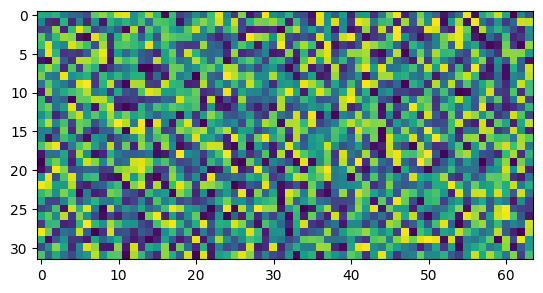

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(d_image.get())

In [ ]:
@jit.rawkernel()
def eraser_kernel(image, nx, ny):

    bid = jit.blockIdx.z * jit.gridDim.x * jit.gridDim.y + \
          jit.blockIdx.y * jit.gridDim.x + jit.blockIdx.x

    tid = jit.threadIdx.z * jit.blockDim.x * jit.blockDim.y + \
          jit.threadIdx.y * jit.blockDim.x + jit.threadIdx.x

    gid = tid + bid * jit.blockDim.x * jit.blockDim.y * jit.blockDim.z

    index_j = cp.int32(cp.int32(gid) // cp.int32(nx))
    index_i = cp.int32(cp.int32(gid) % cp.int32(nx))

    bid = jit.blockIdx.x   # row index
    tid = jit.threadIdx.x   # column index
    # image[bid,tid] --- also possible
    image[tid, bid] = 0

    # image2[i,j] =
    # image[i,j] * pattern[1,1] +
    # image[i-1,j] * pattern[0, 1]+
    # image[i+1,j] * pattern[2, 1]+
    # image[i, j-1] * pattern[1,0] + ...
    #N x M
    #
    #0 .. N x M - 1
    #if (index_i < ...)
    #image[index_i, index_j] = 255



    #    x x x
    #    x o x     --->  image2[i,j]
    #    x x x

/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
eraser_kernel((32,), (32,), (d_image, 32, 64))

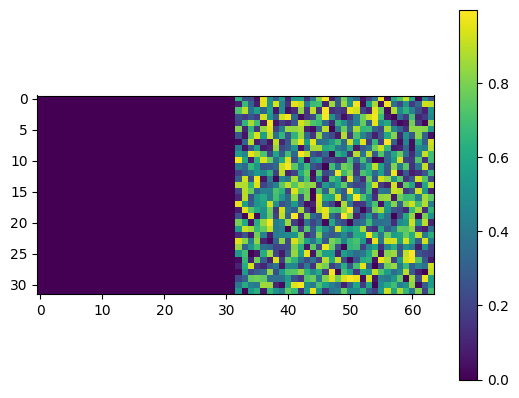

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(d_image.get())
plt.colorbar()

In [ ]:
### свертка  =  прямое Фурье + перемножению Фурье образов + обратное Фурье
### задание со звездочкой

$$
s(t) = \int_{-\infty}^{\infty}f(t-\tau)g(\tau) d\tau
$$

$$
s(\omega)=\int_{-\infty}^{\infty} s(t) e^{i\omega t}dt
$$

$$
s(\omega)=\int_{-\infty}^{\infty}d\tau g(\tau)\int_{-\infty}^{\infty}dt f(t-\tau) e^{i\omega t}
$$

$$
s(\omega)=\int_{-\infty}^{\infty}d\tau g(\tau)e^{i\omega\tau}\int_{-\infty}^{\infty}d(t-\tau) f(t-\tau) e^{i\omega (t-\tau)}
$$

$$
s(\omega) = g(\omega) f(\omega)
$$


Картинка NxN

Шаблон MxM

Свертка попиксельно: $O(N^2 M^2)$

FFT 1D: $N log N$

Шаблон NxN
Свертка через Фурье: $O(N^2 \log^2(N))$

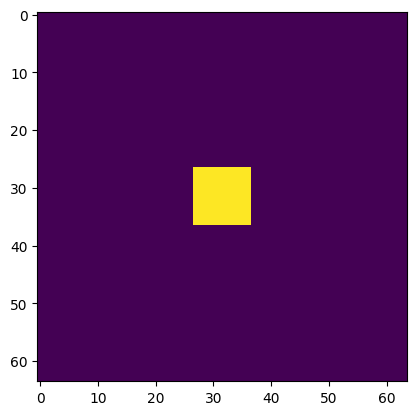

In [ ]:
import numpy as np
N = 64
image = np.random.rand(N,N)
image[10:20, :] = 0
image[:, 20:30] = 0
#plt.imshow(image)

width = 10
pattern = np.ones((width, width))
pattern = np.pad(pattern, N//2-width//2)

plt.imshow(pattern)

In [ ]:
sp_image = np.fft.rfft2(image)
sp_pattern = np.fft.rfft2(pattern)

sp_blur = sp_image * sp_pattern

image_blur = np.fft.ifftshift(np.fft.irfft2(sp_blur))

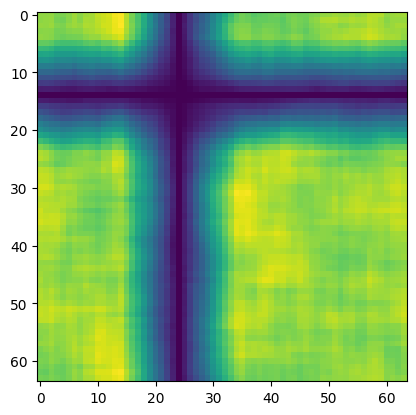

In [ ]:
plt.imshow(image_blur)

In [ ]:
sp_blur_2 = np.fft.rfft2(image_blur)

sp_deblur = sp_blur_2 / (sp_pattern + 1e-10)

image_deblur = np.fft.ifftshift(np.fft.irfft2(sp_deblur))

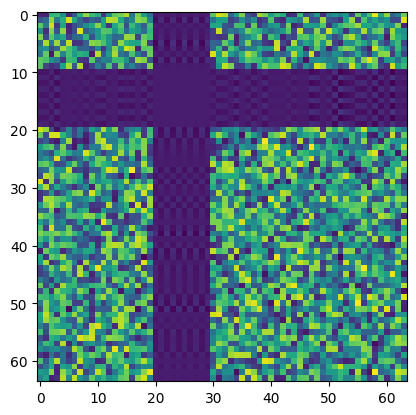

In [ ]:
plt.imshow(image_deblur)

Примеры shared_memory
=======

In [ ]:
import cupy as cp
import time

# Define matrix dimensions
N = 512  # Size of square matrix
BLOCK_SIZE = 16  # Threads per block (16x16)

# Define CUDA kernel (no shared memory)
cuda_kernel_naive = cp.RawKernel(r'''
extern "C" __global__
void matmul_naive(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0;
        for (int k = 0; k < N; ++k) {
            sum += A[row * N + k] * B[k * N + col];  // Directly accessing global memory
        }
        C[row * N + col] = sum;
    }
}
''', 'matmul_naive')

# Generate matrices
A = cp.random.rand(N, N).astype(cp.float32)
B = cp.random.rand(N, N).astype(cp.float32)
C_naive = cp.zeros((N, N), dtype=cp.float32)

# Kernel launch parameters
threads_per_block = (BLOCK_SIZE, BLOCK_SIZE)
blocks_per_grid = (N // BLOCK_SIZE, N // BLOCK_SIZE)

# Measure execution time
start = time.time()
cuda_kernel_naive(blocks_per_grid, threads_per_block, (A, B, C_naive, N))
cp.cuda.Device(0).synchronize()
print("Naive (global memory) execution time:", time.time() - start)


Naive (global memory) execution time: 0.0017349720001220703


In [ ]:
# Define CUDA kernel (with shared memory)
cuda_kernel_shared = cp.RawKernel(r'''

extern "C" __global__
void matmul_shared(float *A, float *B, float *C, int N) {
    __shared__ float Asub[16][16];  // Shared memory for A
    __shared__ float Bsub[16][16];  // Shared memory for B

    int tx = threadIdx.x, ty = threadIdx.y;
    int row = blockIdx.y * blockDim.y + ty;
    int col = blockIdx.x * blockDim.x + tx;

    float sum = 0.0;
    for (int i = 0; i < N / 16; ++i) {
        // Load data into shared memory
        Asub[ty][tx] = A[row * N + (i * 16 + tx)];
        Bsub[ty][tx] = B[(i * 16 + ty) * N + col];
        __syncthreads();

        // Compute partial result using shared memory
        for (int j = 0; j < 16; ++j) {
            sum += Asub[ty][j] * Bsub[j][tx];
        }
        __syncthreads();
    }

    // Write back result
    C[row * N + col] = sum;
}
''', 'matmul_shared')

C_shared = cp.zeros((N, N), dtype=cp.float32)

# Measure execution time
start = time.time()
cuda_kernel_shared(blocks_per_grid, threads_per_block, (A, B, C_shared, N))
cp.cuda.Device(0).synchronize()
print("Shared memory execution time:", time.time() - start)


Shared memory execution time: 0.0010309219360351562


In [ ]:
import cupy as cp
from cupyx import jit

@jit.rawkernel()
def shared_mem_kernel(x, N):
    # Declare shared memory
    smem = jit.shared_memory(float, 32)  # Allocate shared memory for 32 floats

    tid = jit.threadIdx.x
    idx = jit.blockIdx.x * jit.blockDim.x + tid

    if idx < cp.uint32(N):
        smem[tid] = x[idx]  # Load into shared memory
        jit.syncthreads()   # Synchronize threads in block

        # Example operation: Square elements in shared memory
        smem[tid] = smem[tid] * smem[tid]
        jit.syncthreads()   # Sync again before writing

        x[idx] = smem[tid]  # Write back to global memory

# Initialize data
N = 32
block_size = 32
grid_size = (N + block_size - 1) // block_size  # Compute number of blocks

x = cp.arange(N, dtype=cp.float32)  # Example input

# Launch the kernel
shared_mem_kernel[grid_size, block_size](x, N)

print("Output:", x)


/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Output: [  0.   1.   4.   9.  16.  25.  36.  49.  64.  81. 100. 121. 144. 169.
 196. 225. 256. 289. 324. 361. 400. 441. 484. 529. 576. 625. 676. 729.
 784. 841. 900. 961.]


Pinned memory (переносимая закрепленная память)
=======

https://colab.research.google.com/drive/1nEdaEpiNzVFUh9DN5K_hA0BVvopPONDW?usp=sharing


Integration with PyTorch
========

https://docs.cupy.dev/en/stable/user_guide/interoperability.html

1. Рабочий, но не эффективный вариант:
https://colab.research.google.com/drive/1BRcK6d1Z67_gAAQxxjPX1Szk9y1-gNIk?usp=sharing
2. Более правильный вариант
https://colab.research.google.com/drive/1wmEh7H28h0KhRyhTBNScWrXJy_bISSST?usp=sharing

In [ ]:
from IPython import display